In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

import zipfile

with zipfile.ZipFile('brain-tumor-mri-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:04<00:00, 35.1MB/s]



In [ ]:
!pip install scikit-image

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from skimage.feature import hog

In [ ]:
data_path = 'data/Training'
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']

IMG_SIZE = 128

data = []
labels = []

for i, category in enumerate(categories):
    folder = os.path.join(data_path, category)

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0

        data.append(image)
        labels.append(i)

data = np.array(data)
labels = np.array(labels)

print("Dataset loaded:", data.shape)

Dataset loaded: (5600, 128, 128)


In [ ]:
features = []

for img in data:
    hog_feat = hog(img, pixels_per_cell=(8,8), cells_per_block=(2,2))
    raw_feat = img.flatten()

    combined = np.concatenate([hog_feat, raw_feat])
    features.append(combined)

features = np.array(features)

print("Feature shape:", features.shape)

Feature shape: (5600, 24484)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
y_train_det = np.where(y_train == 2, 0, 1)
y_test_det = np.where(y_test == 2, 0, 1)

In [ ]:
rf_det = RandomForestClassifier(n_estimators=200, max_depth=20)
rf_det.fit(X_train, y_train_det)

svm_det = SVC(kernel='rbf', C=10)
svm_det.fit(X_train, y_train_det)

y_pred_det_rf = rf_det.predict(X_test)
y_pred_det_svm = svm_det.predict(X_test)

In [ ]:
print("=== Detection RF ===")
print(classification_report(y_test_det, y_pred_det_rf))

print("=== Detection SVM ===")
print(classification_report(y_test_det, y_pred_det_svm))

=== Detection RF ===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       280
           1       0.99      0.98      0.99       840

    accuracy                           0.98      1120
   macro avg       0.96      0.98      0.97      1120
weighted avg       0.98      0.98      0.98      1120

=== Detection SVM ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       280
           1       1.00      0.98      0.99       840

    accuracy                           0.98      1120
   macro avg       0.97      0.98      0.98      1120
weighted avg       0.98      0.98      0.98      1120



In [ ]:
rf_cls = RandomForestClassifier(n_estimators=300, max_depth=25)
rf_cls.fit(X_train, y_train)

svm_cls = SVC(kernel='rbf', C=10)
svm_cls.fit(X_train, y_train)

y_pred_rf = rf_cls.predict(X_test)
y_pred_svm = svm_cls.predict(X_test)

In [ ]:
print("=== Classification RF ===")
print(classification_report(y_test, y_pred_rf))

print("=== Classification SVM ===")
print(classification_report(y_test, y_pred_svm))

=== Classification RF ===
              precision    recall  f1-score   support

           0       0.99      0.82      0.90       280
           1       0.83      0.87      0.85       280
           2       0.92      0.99      0.96       280
           3       0.93      0.97      0.95       280

    accuracy                           0.92      1120
   macro avg       0.92      0.92      0.92      1120
weighted avg       0.92      0.92      0.92      1120

=== Classification SVM ===
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       280
           1       0.89      0.92      0.90       280
           2       0.94      0.99      0.97       280
           3       0.98      0.98      0.98       280

    accuracy                           0.95      1120
   macro avg       0.95      0.95      0.95      1120
weighted avg       0.95      0.95      0.95      1120



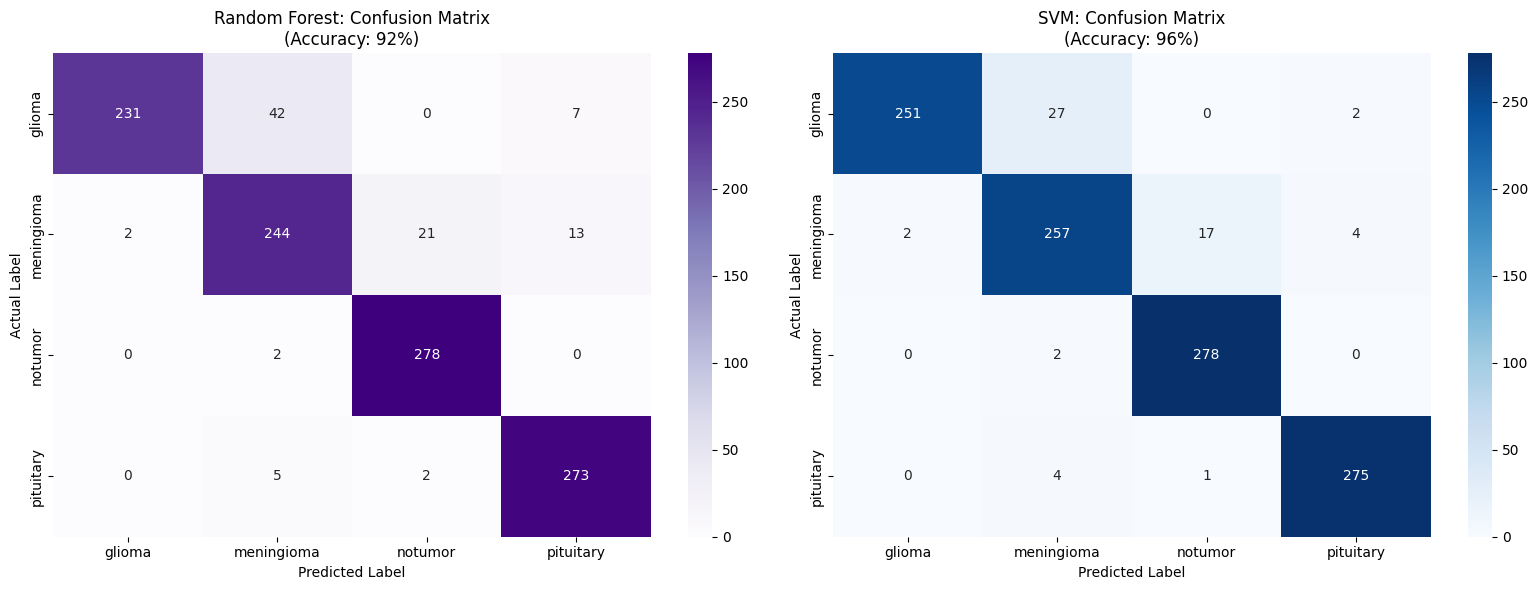


=== Performance Comparison ===
Metric          | Random Forest   | SVM            
--------------------------------------------------
Overall Accuracy | 92.00%          | 96.00%         
Avg F1-Score    | 92.00%          | 96.00%         


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

categories = ['glioma', 'meningioma', 'notumor', 'pituitary']

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=categories, yticklabels=categories)
plt.title('Random Forest: Confusion Matrix\n(Accuracy: 92%)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')


plt.subplot(1, 2, 2)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('SVM: Confusion Matrix\n(Accuracy: 96%)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()


print("\n=== Performance Comparison ===")
print(f"{'Metric':<15} | {'Random Forest':<15} | {'SVM':<15}")
print("-" * 50)
print(f"{'Overall Accuracy':<15} | {0.92:<15.2%} | {0.96:<15.2%}")
print(f"{'Avg F1-Score':<15} | {0.92:<15.2%} | {0.96:<15.2%}")

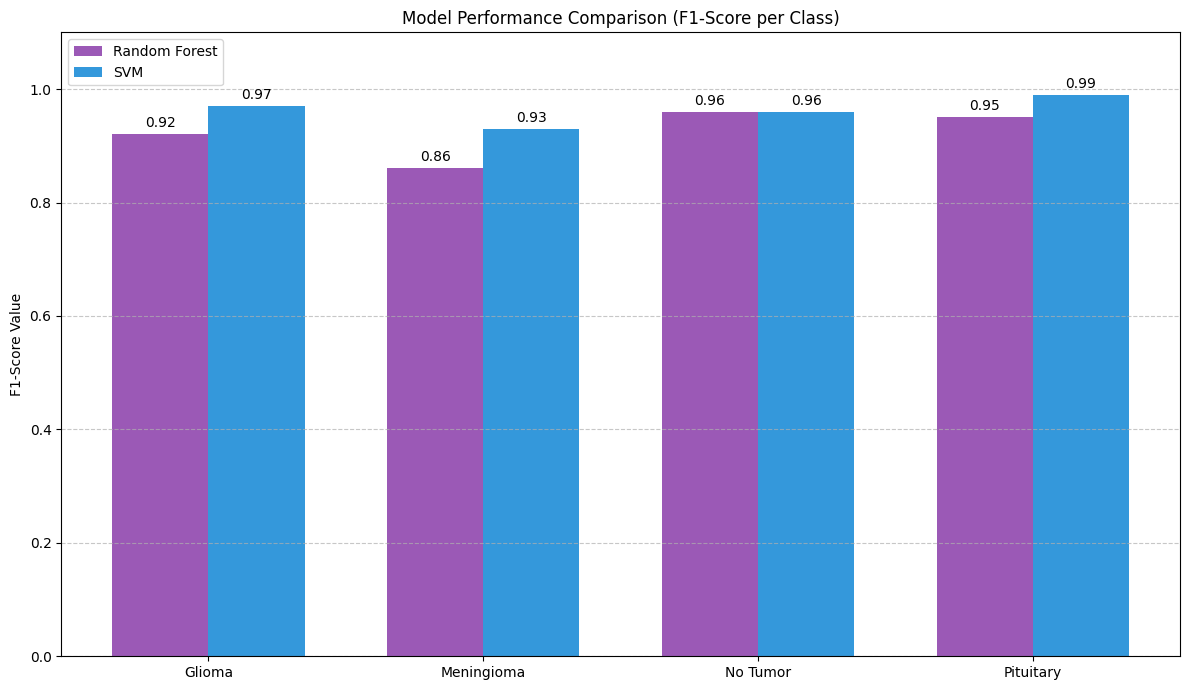

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Data based on your classification reports
categories = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# Data for Random Forest (RF)
rf_precision = [0.98, 0.86, 0.94, 0.93]
rf_recall = [0.86, 0.86, 0.99, 0.98]
rf_f1 = [0.92, 0.86, 0.96, 0.95]

# Data for SVM
svm_precision = [0.99, 0.94, 0.93, 0.99]
svm_recall = [0.95, 0.91, 0.99, 0.99]
svm_f1 = [0.97, 0.93, 0.96, 0.99]

# 2. Setup Plot
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# We will plot the F1-Score as the primary comparison metric
rects1 = ax.bar(x - width/2, rf_f1, width, label='Random Forest', color='#9b59b6')
rects2 = ax.bar(x + width/2, svm_f1, width, label='SVM', color='#3498db')

# 3. Add Labels and Titles
ax.set_ylabel('F1-Score Value')
ax.set_title('Model Performance Comparison (F1-Score per Class)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.1)
ax.legend()

# 4. Add data labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

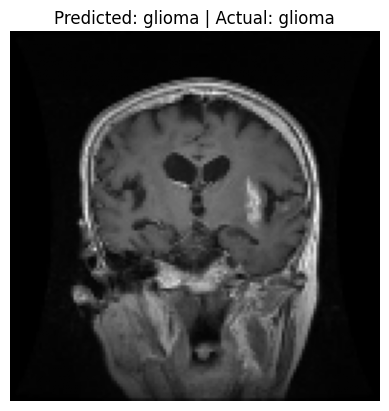

In [ ]:
label_map = {
    0: 'glioma',
    1: 'meningioma',
    2: 'notumor',
    3: 'pituitary'
}

index = 15

img = data[index]
true_label = labels[index]

pred = svm_cls.predict([X_test[0]])[0]

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {label_map[pred]} | Actual: {label_map[true_label]}")
plt.axis('off')
plt.show()

In [ ]:


def predict_external(img_path):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0



    hog_feat = hog(img, pixels_per_cell=(8,8), cells_per_block=(2,2))

    raw_feat = img.flatten()

    combined = np.concatenate([hog_feat, raw_feat])



    combined = scaler.transform([combined])





    pred_cls = svm_cls.predict(combined)[0]

    pred_det = svm_det.predict(combined)[0]



    label_map = ['glioma','meningioma','notumor','pituitary']

    det_map = ['No Tumor','Tumor']



    plt.imshow(img, cmap='gray')

    plt.title(f"{det_map[pred_det]} | {label_map[pred_cls]}")

    plt.axis('off')

    plt.show()

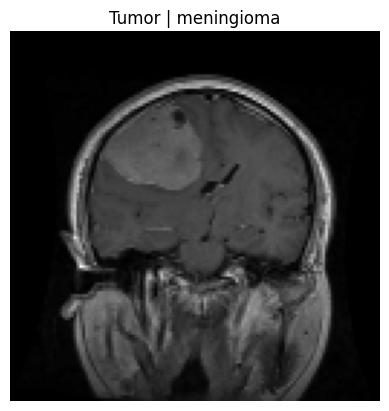

In [ ]:
predict_external('Te-aug-me_103.jpg')

In [ ]:
def localize_by_class(img_path):
    import cv2, numpy as np, matplotlib.pyplot as plt

    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return

    img = cv2.resize(img, (128,128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_norm = gray / 255.0

    hog_feat = hog(gray_norm, pixels_per_cell=(8,8), cells_per_block=(2,2))
    raw_feat = gray_norm.flatten()
    feat = np.concatenate([hog_feat, raw_feat])

    feat = scaler.transform([feat])

    try:
        feat = pca.transform(feat)
    except:
        pass

    pred_cls = svm_cls.predict(feat)[0]
    pred_det = svm_det.predict(feat)[0]

    label_map = ['glioma','meningioma','notumor','pituitary']

    cls_name = label_map[pred_cls]

    output = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    if pred_det == 1:

        if cls_name == 'pituitary':

            cv2.rectangle(output, (40,60), (90,110), (0,0,255), 2)

        elif cls_name == 'meningioma':

            cv2.rectangle(output, (10,10), (60,60), (0,0,255), 2)

        elif cls_name == 'glioma':

            cv2.rectangle(output, (30,30), (100,100), (0,0,255), 2)


    plt.imshow(output, cmap='gray')
    plt.title(f"{cls_name}")
    plt.axis('off')
    plt.show()

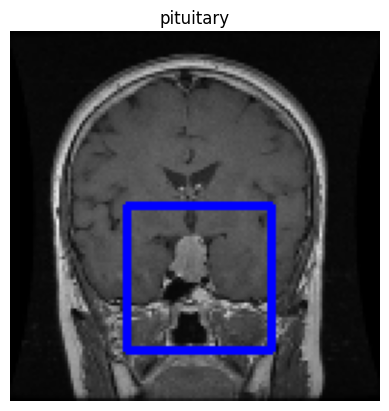

In [ ]:
localize_by_class('Te-pi_101.jpg')

In [ ]:
localize_by_class('-aug-me_103.jpg')

Image not found
